# Proyecto Integrador: Predictor de demanda para redes eléctricas

## Comprensión del negocio

En este bloque se explora a grandes rasgos los objetivos, fuentes, preparaciones pertinentes y evaluaciones que se realizarán a lo largo del proyecto.

| Bloque | Fase | Descripción |
| --- | --- | --- |
| Objetivo del negocio | Negocio | Predecir la demanda energética para optimizar el uso de fuentes renovables. |
| Valor del proyecto | Negocio | - **Económico:** Optimización de costes de infraestructura, venta de posibles excedentes de energía y menor dependencia de combustibles fósiles. <br><br> - **Medio ambiente:** Reducción en la contaminación del medio ambiente mediante el uso de fuentes renovables. |
| Fuentes de datos | Datos | - **API Red Eléctrica:** API con datos de Red Eléctrica España públicos. https://www.ree.es/es/datos/apidatos <br><br> - **Historial Climático:** Archivo excel con el histórico del clima publicado por la AEMET desde el 2013 hasta la actualidad. https://datosclima.es/Aemet2013/DescargaDatos.html <br><br> - **Calendario Laboral y Festivos:** Librería `holidays` para detectar cuando una fecha es festiva o no en la región. Fichero csv con el calendario de festividades por regiones en su defecto. <br><br> - **Precio diario del Mercado:** A través de la API de Red Eléctrica para predecir con mayor exactitud los precios en función de la demanda y la disponibilidad de energía renovable. |
| Variable objetivo | Datos | **Numérica:** Predicción de consumo para un día determinado en MW. |
| Calidad y riesgos | Datos | - **Calidad:** Pueden existir valores no válidos en los datos obtenidos por la API o el historial climático. <br><br> **Riesgos:** La demanda energética puede depende del calendario (festivos, fines de semana, vacaciones, estaciones...). |
| Preparación y features | Preparación | - Limpieza de datos (filtrado de outliers y nulos, transformaciones, etc.). <br><br> - Creación de variables temporales: `es_festivo`, `es_fin_de_semana`. <br><br> - Inclusión de datos históricos de España desde el 2013 como predictores. <br><br> - Arquitectura de datos con AWS S3 para capas bronce y plata, AWS Lambda y procesamiento local con Pandas. |
| Modelado | Modelado | Uso de algoritmos de regresión basados en series temporales. |
| Evaluación (KPIs) | Evaluación | - **Técnico:** - Obtener un MAPE (Mean Absolute Percentage Error) < 5% y reducir al máximo posible el RMSE (Root Mean Square Error). <br><br> - **Negocio:** Traducir la predicción obtenida en una optimización real; reducción de costes por venta de energía y mayor aprovechación de la cuota de la generación renovable. |
| Despliegue y uso | Despliege | Panel de control o dashboard interactivo para representar los valores de forma rápida y visual. |

## Comprensión de los datos

En este bloque se realizará una exploración rápida sobre los datos disponibles, identificaciones de posibles relaciones y/o modificaciones y transformaciones que puedan ser adecuadas más adelante. 

*Instalación, importaciones de librerías necesarias y definiciones base.*

In [2]:
# Instalaciones
!pip install boto3
!pip install lxml
!pip install beautifulsoup4
!pip install rarfile
!pip install xlrd
!pip install entsoe-py
!pip install holidays

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 8.7 MB/s eta 0:00:00
  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.8.2
    Uninstalling python-dateutil-2.8.2:
      Successfully uninstalled python-dateutil-2.8.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.4.4 which is incompatible.


In [2]:
# Importaciones y definiciones base
import datetime
import boto3
import pandas as pd
import requests
from urllib.parse import urljoin
import rarfile
import subprocess
import os
import shutil
import io
import holidays
from bs4 import BeautifulSoup
from requests.exceptions import Timeout, RequestException

API_REE_URL = "https://apidatos.ree.es"
DATOS_CLIMA = "https://datosclima.es/Aemet2013/DescargaDatos.html"

BUCKET_BRONCE = "ksc-proyecto-integrador-bronce"
BUCKET_PLATA = "ksc-proyecto-integrador-plata"

DIR_TEMP = "./tempfiles"

rarfile.UNRAR_TOOl = "/opt/conda/bin/unrar"

def connect_s3():
    try:
        s3 = boto3.client("s3")
        print("Conexión establecida.")
    except Exception as e:
        print("Error de conexión.")
        print(e)

    return s3

def upload_raw_data_to_s3(s3, bucket, filename, data):
    print("Subiendo datos a S3 desde memoria")
    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
    existe_bucket = bucket in buckets

    if not existe_bucket:
        s3.create_bucket(Bucket = bucket)

    # Para mantener el df en memoria sin escribirlo al disco
    csv_buffer = io.StringIO()
    data.to_csv(csv_buffer, index = False)

    # s3_key = filename.replace(".xls", ".csv")
    s3_key = filename.replace("-", "/")
    s3_key = os.path.splitext(s3_key)[0]
    s3_key = f"{s3_key}.csv"
    
    s3.put_object(
            Bucket = bucket,
            Key = s3_key,
            Body = csv_buffer.getvalue().encode("utf-8")
        )
    print(f"Datos subidos con éxito a s3://{bucket}/{s3_key}")

def upload_from_disk_to_s3(s3, bucket, path, data):
    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
    existe_bucket = bucket in buckets

    if not existe_bucket:
        s3.create_bucket(Bucket = bucket)

    s3.upload_file(data, bucket, path)
    print(f"Datos subidos con éxito a s3://{bucket}/{path}")

def download_from_s3(s3, bucket, object_path):
    download_path = os.path.join("s3_downloads", object_path)

    try:
        print(f"Descargando desde s3: s3//{bucket}/{object_path}")
        s3.download_file(bucket, object_path, download_path)
        print(f"Archivo descargado y almacenado en: {download_path}")
    except Exception as e:
        print(f"ERROR: {e}")

Los datos con los que se van a trabajar provienen de: 
- [API de entso-e (Red de transparencia)](https://transparency.entsoe.eu/)
- [Datos Clima publicados por la AEMET desde el 2013](https://datosclima.es/Aemet2013/DescargaDatos.html)
- Calendario laboral y festivos ([librería holiday](https://pypi.org/project/holidays/))

### API ENTSO-E

La red de transpariencia ENTSO-E provee de datos eléctricos de toda Europa de consumo, demanda, generación... Esta sección se centra en la obtención de datos de generación con sus diferentes fuentes.

In [25]:
from entsoe import EntsoePandasClient

ENTSOE_KEY = ""
SPAIN_CODE = "ES"

with open("entsoe-key.txt") as f:
    ENTSOE_KEY = f.read().strip()

if not ENTSOE_KEY:
    raise ValueError("No se ha encontrado la key de la API de ENTSOE. Crea un fichero .txt con la clave.")

def connect_entsoe():
    entsoe = EntsoePandasClient(ENTSOE_KEY)
    return entsoe

def get_entsoe_data(entsoe_client, year):
    print(f"Descargando los datos brutos de generación de energía de ENTSO-E del año {year}")

    start = pd.Timestamp(f"{year}-01-01", tz="Europe/Madrid")
    end = pd.Timestamp(f"{year}-12-31T23:59", tz="Europe/Madrid")

    try:
        df_raw_entsoe = entsoe_client.query_generation(SPAIN_CODE, start = start, end = end)

        # A veces devuelve un MultiIndex de pandas (el de las plantas). Con esto se aplana.
        if isinstance(df_raw_entsoe.columns, pd.MultiIndex):
            df_raw_entsoe = df_raw_entsoe.xs("Actual Aggregated", axis = 1, level = 1)

        # Se pone la fecha y hora como el índice. Limpia el índice y la pasa a una columna
        df_raw_entsoe = df_raw_entsoe.reset_index().rename(columns = {"index": "Datetime"})
        return df_raw_entsoe
    except Exception as e:
        print(f"ERROR: {e}")

In [27]:
s3 = connect_s3()

# 2027 porque no lo incluye
for i in range(2020, 2027):
    raw_entsoe = get_entsoe_data(connect_entsoe(), i)
    upload_raw_data_to_s3(s3, BUCKET_BRONCE, f"entsoe/year={i}/raw_{i}", raw_entsoe)

Conexión establecida.
Descargando los datos brutos de generación de energía de ENTSO-E del año 2020
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2020/raw_2020.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2021
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2021/raw_2021.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2022
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2022/raw_2022.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2023
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2023/raw_2023.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2024
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integr

El código anterior recopila datos de la API de entso-e y los sube a a la capa bronce en S3.

Los datos obtenidos por la API de entso-e vienen en inglés y son horarios. Existe una función lambda en AWS que se lanza cuando se sube un archivo con prefijo `entsoe/` para poder pasar los nombres de las columnas a español, unificar los datos para que sean diarios en lugar de horarios y pasarlo a parquet. Luego los guarda en la capa bronce en el formato `energia_consolidada/year=año/energia_año.parquet`.

Función Lambda:

```python
import json
import urllib.parse
import boto3
import pandas as pd
import awswrangler as wr
import io

TRANSLATION_ENTSOE = {
    "datetime": "fecha_hora",
    "Biomass": "biomasa_mwh",
    "Fossil Brown coal/Lignite": "carbon_marron_lignito_mwh",
    "Fossil Coal-derived gas": "gas_derivado_carbon_mwh",
    "Fossil Gas": "gas_natural_mwh",
    "Fossil Hard coal": "hulla_antracita_mwh",
    "Fossil Oil": "petroleo_mwh",
    "Fossil Oil shale": "esquisto_bituminoso_mwh",
    "Fossil Peat": "turba_mwh",
    "Geothermal": "geotermica_mwh",
    "Hydro Run-of-river and poundage": "hidraulica_fluyente_mwh",
    "Hydro Water Reservoir": "hidraulica_embalse_mwh",
    "Marine": "maritima_mwh",
    "Nuclear": "nuclear_mwh",
    "Other": "otras_tecnologias_mwh",
    "Other renewable": "otras_renovables_mwh",
    "Solar": "solar_fotovoltaica_mwh",
    "Waste": "residuos_mwh",
    "Wind Offshore": "eolica_marina_mwh",
    "Wind Onshore": "eolica_terrestre_mwh"
}

BUCKET_PLATA = "ksc-proyecto-integrador-plata"

def lambda_handler(event, context):
    bucket_bronce = event["Records"][0]["s3"]["bucket"]["name"]
    key_bronce = urllib.parse.unquote_plus(event["Records"][0]["s3"]["object"]["key"], encoding = "utf-8")

    # entsoe/year=2020/raw_data_2020.csv
    year = key_bronce.split("=")[1].split("/")[0]

    try:
        df_raw = wr.s3.read_csv(path = f"s3://{bucket_bronce}/{key_bronce}")

        df_raw["Datetime"] = pd.to_datetime(df_raw["Datetime"], utc = True)
        df_raw = df_raw.set_index("Datetime")

        cols = [c for c in TRANSLATION_ENTSOE.keys() if c in df_raw.columns]
        df_final = df_raw[cols].rename(columns = TRANSLATION_ENTSOE)

        # Convierte los registros horarios a diarios
        df_daily = df_final.resample("D").sum().reset_index()
        df_daily["fecha"] = df_daily["Datetime"].dt.date
        df_daily.drop(columns = ["Datetime"], inplace = True)

        path = f"s3://{BUCKET_PLATA}/energia_consolidada/year={year}/energia_{year}.parquet"

        wr.s3.to_parquet(
            df = df_daily, 
            path = path, 
            index = False
        )

    except Exception as e:
        print(f"ERROR: {e}")


```

### Datos del clima publicados por la AEMET

Fuente: https://datosclima.es/Aemet2013/DescargaDatos.html

En esta página se encuentran datos publicados por la AEMET desde mayo del 2013 y recogidos de forma libre. Los diferentes enlaces de descarga se encuentran en formato de tabla, divididas por año y mes.

Como descargar uno a uno estos archivos serían un proceso lento y tedioso, se procede a realizar un trabajo de *web scraping* (raspado de web) para las descarga y almacenamiento en AWS S3 de los datos.

In [10]:
def unpack_rar(url, filename, dir = DIR_TEMP):
    filename = filename.split("/")[-1] # Si añade la barra rompe la ruta

    # Comprueba que el directorio existe para borrarlo recursivamente y crearlo otra vez
    if os.path.exists(dir):
        shutil.rmtree(dir)    
    os.makedirs(dir)

    rar_path = os.path.join(dir, filename)

    try:
        print(f"Descargando: {url}")

        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
            'Referer': 'https://datosclima.es/Aemet2013/DescargaDatos.html'
        }
        
        response = requests.get(url, stream = True, timeout = (3, 10), headers = headers)
        response.raise_for_status()

        with open(rar_path, "wb") as file:
            for chunk in response.iter_content(chunk_size = 8192):
                file.write(chunk)

        file_kb = os.path.getsize(rar_path)
        if file_kb < 1000:
            print("ERROR: El servidor no ha enviado un .rar")
            with open(rar_path, "r", encoding = "utf-8", errors = "ignore") as f:
                print(f.read())
            return

        print("Descomprimiendo...")
        final_path = os.path.join(dir, "")
        command = ["unrar", "x", "-y", rar_path, final_path]

        process = subprocess.run(command, capture_output = True, text = True)
        print(f"Número de elementos descomprimidos: {len(os.listdir(dir)) - 1}") # -1 porque guarda el .rar también
        return True
    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")
        return False
    except Exception as e:
        print(f"ERROR: {e}")
        return False
    # quiza deberia meter un finally para eliminar la carpeta de tempfiles al acabar

def convert_files_to_df():
    dfs = []
    
    print("Convirtiendo de excel a DataFrame de pandas")
    tempfiles_path = "tempfiles"
    
    if os.path.exists(tempfiles_path):
        for file in os.listdir(tempfiles_path):
            if file.endswith(".xls"):
                path = os.path.join(tempfiles_path, file)
                try:
                    df = pd.read_excel(path, engine = "xlrd", skiprows = 4)
                    
                    df["archivo_origen"] = file # por si lo necesito más adelante
                    dfs.append((file, df))
                except Exception:
                    # Algún fichero daba error de corrupción o formato
                    continue
    return dfs

# def convert_to_parquet(dfs):
#     print("Convirtiendo de DataFrame de pandas a parquet")
#     path = "parquet"
#     for df in dfs:
#         full_path = os.path.join(path, df.name)
#         df.to_parquet(full_path)

def get_aemet2013_data():
    s3 = connect_s3()
    
    try:
        response = requests.get(DATOS_CLIMA, timeout = (3, 10))
        response.raise_for_status()
        response.encoding = "utf-8"
        
        soup = BeautifulSoup(response.text, "html.parser")
    
        # Captura todos los enlaces en la página
        links = soup.find_all("a")
    
        for link in links:
            path = link.get("href")
    
            if "../capturadatos/" in path:
                full_url = urljoin("https://datosclima.es", path)
                if unpack_rar(full_url, path):
                    dfs = convert_files_to_df()

                    for filename, df in dfs:
                        upload_raw_data_to_s3(s3, BUCKET_BRONCE, filename, df)
    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")
    except RequestException as e:
        print(f"ERROR: {e}")

In [11]:
get_aemet2013_data()

Conexión establecida.
Descargando: https://datosclima.es/capturadatos/Aemet2013-05.rar
Descomprimiendo...
Número de elementos descomprimidos: 25
Convirtiendo de excel a DataFrame de pandas
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/07.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/08.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/09.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/10.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/11.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/12.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/13.csv

Para utilizar la librería `rarfile` hace falta tener WinRar o `unrar` instalados en la máquina para poder descomprimir. Como este notebook se asienta en un contenedor de docker con la imagen `jupyter/datascience-notebook` ha sido necesario instalarlo desde `conda` en lugar de hacer el usual `apt-get` que se haría en cualquier caso por falta de permisos. Comando: 

`conda install -c conda-forge unrar -y`

#### Estructura de datos

Los datos se estructuran en unas tablas en la propia web:

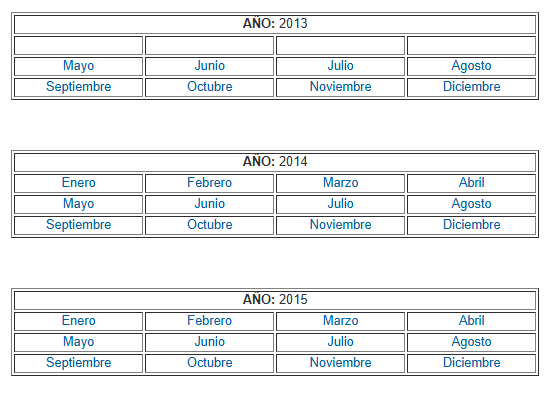

Cada tabla es un año con sus meses. Cada mes es un enlace a un `.rar` que contiene datos de cada día del mes. Así pues, se entiende que al descargar un fichero se descomprime en 30-31 xls.

Se almacenan en AWS S3 por año/mes/(resto de días del mes)

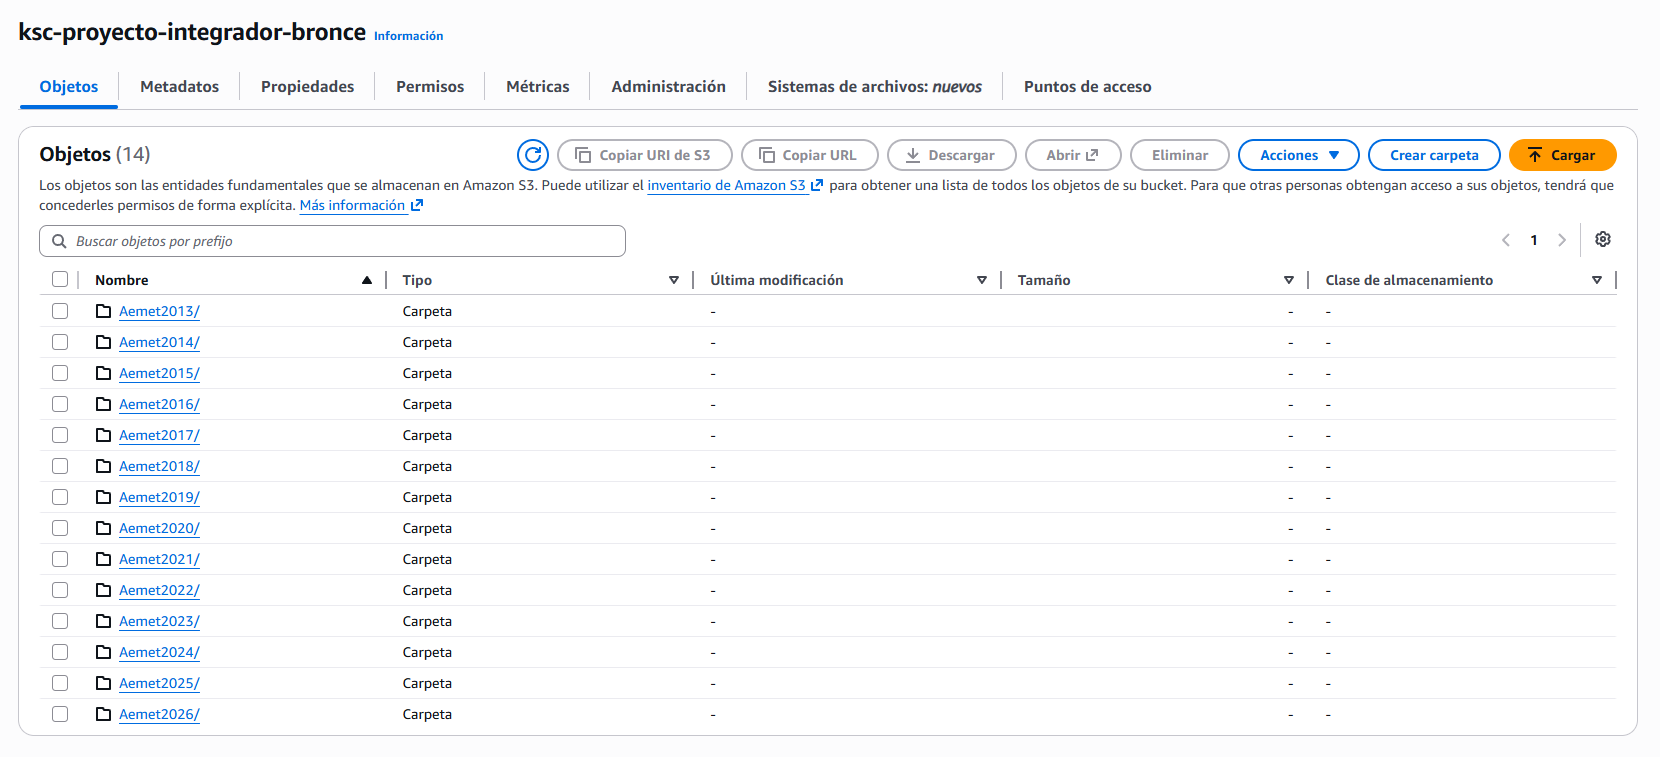

## Librería Holidays

Esta librería permite obtener los días festivos de diferentes zonas del mundo, incluidas las Comunidades Autónomas de España.

Este proceso se llevará a cabo con una función lambda, que se disparará al subir los datos de la AEMET. Su función será añadir en el csv si el día era festivo o no y guardará el objeto en la capa plata.

Además, como las funciones lambda de AWS se cobran por invocación y tiempo de ejecución, se filtrarán los datos para que sólo se aplique a los datos desde 2020 hasta 2026.

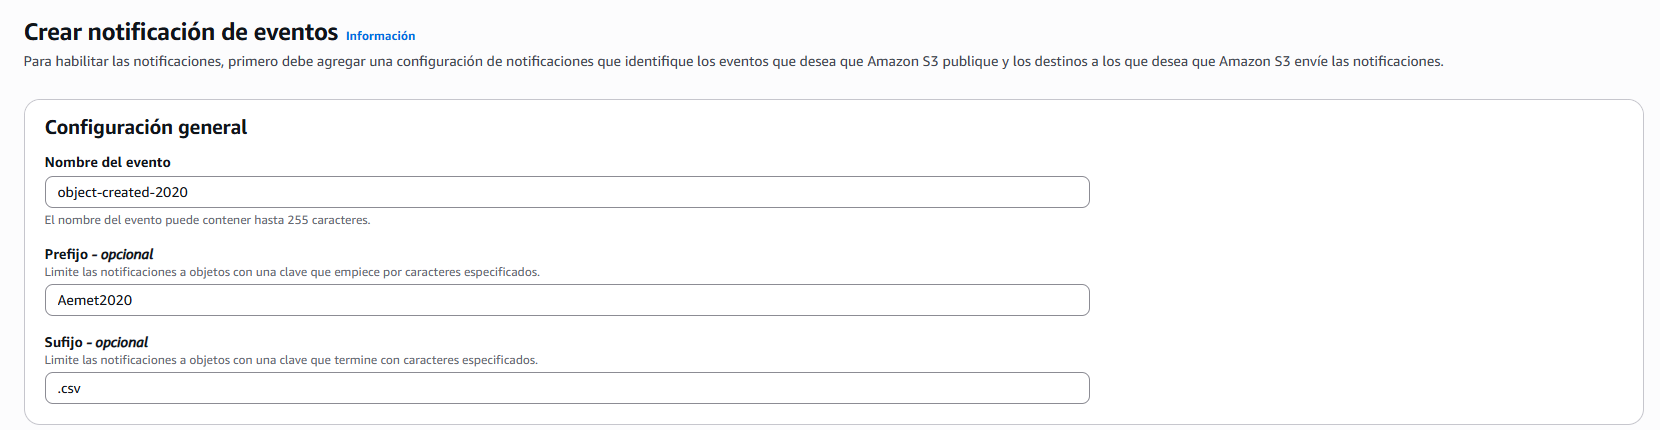
Se crea una notificación por año (Aemet2020, Aemet2021...)
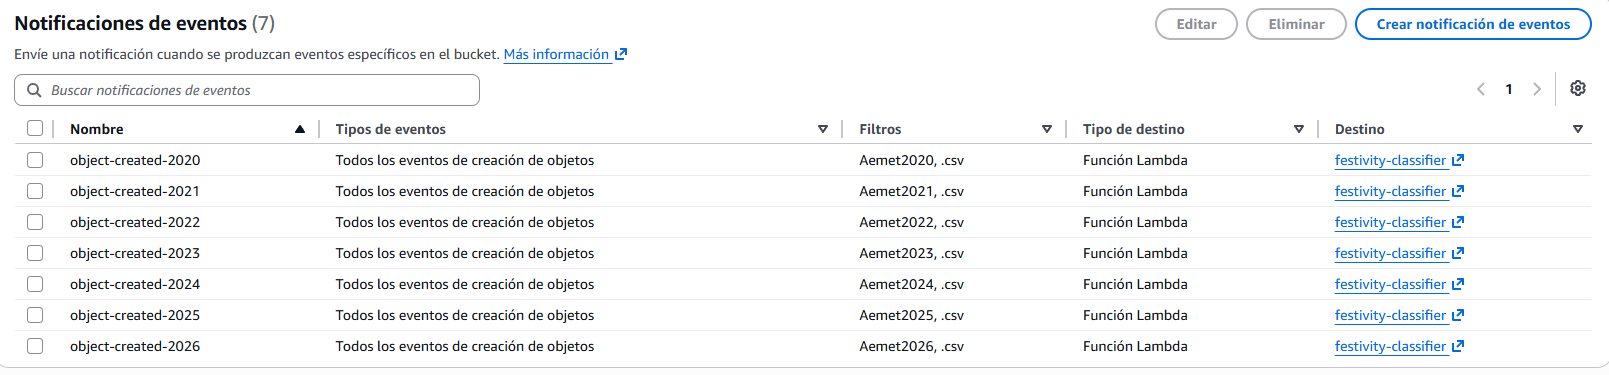

Función Lambda:

```python
import json
import urllib.parse
import boto3
import pandas as pd
import holidays
from datetime import datetime
import io

s3_client = boto3.client('s3') # lo creo fuera del handler para poder reutilizar la conexión

PROVINCIAS_CCAA = {
    # Andalucía (AN)
    'ALMERÍA': 'AN', 'CÁDIZ': 'AN', 'CÓRDOBA': 'AN', 'GRANADA': 'AN', 
    'HUELVA': 'AN', 'JAÉN': 'AN', 'MÁLAGA': 'AN', 'SEVILLA': 'AN',
    # Aragón (AR)
    'HUESCA': 'AR', 'TERUEL': 'AR', 'ZARAGOZA': 'AR',
    # Principado de Asturias (AS)
    'ASTURIAS': 'AS',
    # Canarias (CN)
    'LAS PALMAS': 'CN', 'SANTA CRUZ DE TENERIFE': 'CN',
    # Cantabria (CB)
    'CANTABRIA': 'CB',
    # Castilla y León (CL)
    'ÁVILA': 'CL', 'BURGOS': 'CL', 'LEÓN': 'CL', 'PALENCIA': 'CL', 
    'SALAMANCA': 'CL', 'SEGOVIA': 'CL', 'SORIA': 'CL', 'VALLADOLID': 'CL', 'ZAMORA': 'CL',
    # Castilla-La Mancha (CM)
    'ALBACETE': 'CM', 'CIUDAD REAL': 'CM', 'CUENCA': 'CM', 'GUADALAJARA': 'CM', 'TOLEDO': 'CM',
    # Cataluña (CT)
    'BARCELONA': 'CT', 'GIRONA': 'CT', 'GERONA': 'CT', 'LLEIDA': 'CT', 'LÉRIDA': 'CT', 'TARRAGONA': 'CT',
    # Extremadura (EX)
    'BADAJOZ': 'EX', 'CÁCERES': 'EX',
    # Galicia (GA)
    'A CORUÑA': 'GA', 'LA CORUÑA': 'GA', 'LUGO': 'GA', 'OURENSE': 'GA', 'ORENSE': 'GA', 'PONTEVEDRA': 'GA',
    # Illes Balears (IB)
    'BALEARES': 'IB', 'ILLES BALEARS': 'IB', 'ISLAS BALEARES': 'IB',
    # La Rioja (RI)
    'LA RIOJA': 'RI',
    # Comunidad de Madrid (MD)
    'MADRID': 'MD',
    # Región de Murcia (MC)
    'MURCIA': 'MC',
    # Comunidad Foral de Navarra (NC)
    'NAVARRA': 'NC',
    # País Vasco (PV)
    'ÁLAVA': 'PV', 'ARABA': 'PV', 'GUIPÚZCOA': 'PV', 'GIPUZKOA': 'PV', 'VIZCAYA': 'PV', 'BIZKAIA': 'PV',
    # Comunidad Valenciana (VC)
    'ALICANTE': 'VC', 'ALACANT': 'VC', 'CASTELLÓN': 'VC', 'CASTELLÓ': 'VC', 'VALENCIA': 'VC', 'VALÈNCIA': 'VC',
    # Ciudades Autónomas
    'CEUTA': 'CE',
    'MELILLA': 'ML'
}

BUCKET_DESTINO = "ksc-proyecto-integrador-meteo-y-vacaciones"

def lambda_handler(event, context):
    bucket = event["Records"][0]["s3"]["bucket"]["name"]
    key = urllib.parse.unquote_plus(event["Records"][0]["s3"]["object"]["key"], encoding="utf-8")

    print(f"Procesando: {key} de {bucket}")

    try:
        response = s3_client.get_object(Bucket = bucket, Key = key)
        path_splitted = key.split("/")

        year = int(path_splitted[0].replace("Aemet", ""))
        month = int(path_splitted[1])
        day = int(path_splitted[2].replace(".csv", ""))

        if year < 2020:
            print("ERROR: El fichero era anterior a 2020.")
            return
        
        df = pd.read_csv(io.BytesIO(response["Body"].read()))

        # Si no pongo la fecha en formato de pandas da errores
        current_date = pd.to_datetime(f"{year}-{month}-{day}")
        df["fecha"] = current_date

        # Separa la provincia en 2 partes (Alacant/Alicante) para quedarse con la última
        df["Provincia_Limpia"] = df["Provincia"].str.split('/').str[-1]
        df["ccaa_codigo"] = df["Provincia_Limpia"].str.strip().str.upper().map(PROVINCIAS_CCAA)
        
        df["es_festivo"] = 0

        # Es posible que deje algunas sin mapear sin darme cuenta, así que me dejo de problemas con esto
        ccaa_dataset = df["ccaa_codigo"].dropna().unique()

        for ccaa in ccaa_dataset:
            # Obtiene festivos para la comunidad autónoma específica
            country_holidays = holidays.ES(subdiv = ccaa, years = year)

            if current_date in country_holidays:
                df.loc[df['ccaa_codigo'] == ccaa, 'es_festivo'] = 1
        
        s3_client.put_object(
            Bucket = BUCKET_DESTINO,
            Key = f"{key}",
            Body = df.to_csv(index = False),
            ContentType = "text/csv"
        )
        print(f"Fichero procesado y almacenado en: {BUCKET_DESTINO}/{key}")
    except Exception as e:
        print(e)
        raise e

```

Esta función requirió de la creación de capas (Pandas y Holidays) y de asignación de memoria extra.

## Compactación de datos

Como se ha indicado, los datos almacenados en la capa bronce están divididos en ficheros `.csv` por día. Su estructura es como la siguiente:

- Aemet2020/
    - 01/
        - 01.csv
        - 02.csv
        - 03.csv
        - resto de días
    - 02/
        - 01.csv
        - 02.csv
        - 03.csv
        - resto de días
    - resto de meses
- Resto de años

Esta estructura es un problema para su posterior procesamiento, por lo que se van a compactar los datos por años. Para ello se lanzará una función manual.

*La idea inicial era lanzar una regla promada Cron desde EventBridge para que se ejecutase automáticamente cada mes o cada año, dependiendo de las necesidades. Pero para evitar esperas se creará una función Lambda que se invocará manualmente desde este código. El código de la función Lambda puede ser configurado perfectamente para una regla definida en EventBridge.*

Código de la función Lambda:

```python
import json
import pandas as pd
import awswrangler as wr

BUCKET_METEO_VACACIONES = "ksc-proyecto-integrador-meteo-y-vacaciones"
BUCKET_PLATA = "ksc-proyecto-integrador-plata"

def lambda_handler(event, context):
    year = event.get("year", "")

    if not year:
        raise ValueError("No se ha especificado el año.")

    print(f"Iniciando compactación para el año: {year}")

    try:
        target_path = f"s3://{BUCKET_METEO_VACACIONES}/Aemet{year}/"
        df_anual = wr.s3.read_csv(path = target_path)

        # Formato Hive/Spark
        target_path = f"s3://{BUCKET_PLATA}/aemet_consolidada/year={year}/aemet_historico_{year}.parquet"

        if not df_anual.empty:
            wr.s3.to_parquet(
            df = df_anual,
            path = target_path,
            index = False
        )
        
    except Exception as e:
        print(ROR: {e}")
        raise e




```